# Detection of Male and Female Eyes from image Dataset

## Using CNN

In [1]:
pip install keras_preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.4 MB/s eta 0:00:00


In [3]:
# Import the required modules
import numpy as np
import pandas as pd
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt


# Use Dataset from https://www.kaggle.com/datasets/pavelbiz/eyes-rtte

### This Dataset contains ~11K images of human eye photographs separated into two directories
#### Complete this notebook to demonstrates training and testing a simple keras binary classification CNN

In [2]:
! pip install kaggle

In [4]:
! kaggle datasets download pavelbiz/eyes-rtte

Dataset URL: https://www.kaggle.com/datasets/pavelbiz/eyes-rtte
License(s): copyright-authors
100% 40.4M/40.4M [00:00<00:00, 104MB/s] 



In [5]:
!mkdir /content/eyes_dataset2
! mkdir train_eye_dataset2

In [6]:
! unzip /content/eyes-rtte.zip -d /content/eyes_dataset2

Streaming output truncated to the last 5000 lines.
  inflating: /content/eyes_dataset2/maleeyes/2430.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2431.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2432.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2433.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2434.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2435.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2436.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2437.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2438.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2439.jpg  
  inflating: /content/eyes_dataset2/maleeyes/244.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2440.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2441.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2442.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2443.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2444.jpg  
  inflating: /content/eyes_dataset2/maleeyes/2445.jpg 

### Data Preprocessing and Augmentation

In [7]:
TRAINING_DIR = '/content/eyes_dataset2'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2 # Use 20% of data for validation
)

train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 9221 images belonging to 2 classes.
Found 2304 images belonging to 2 classes.


### Model Definition

In [8]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') # Binary classification
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

In [9]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])


### Model Training

In [12]:
history = model.fit(
    train_generator,
    epochs=2, # You can adjust the number of epochs
    validation_data=validation_generator,
    verbose=1
)


Epoch 1/2
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5683 - loss: 0.6835

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


289/289 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - accuracy: 0.5838 - loss: 0.6785 - val_accuracy: 0.6024 - val_loss: 0.6624
Epoch 2/2
289/289 ━━━━━━━━━━━━━━━━━━━━ 590s 2s/step - accuracy: 0.6610 - loss: 0.6188 - val_accuracy: 0.6827 - val_loss: 0.6231


### Save the Trained Model

In [13]:
model.save('model.keras')
print("Model saved as 'model.keras'")


Model saved as 'model.keras'


### Plotting Training History

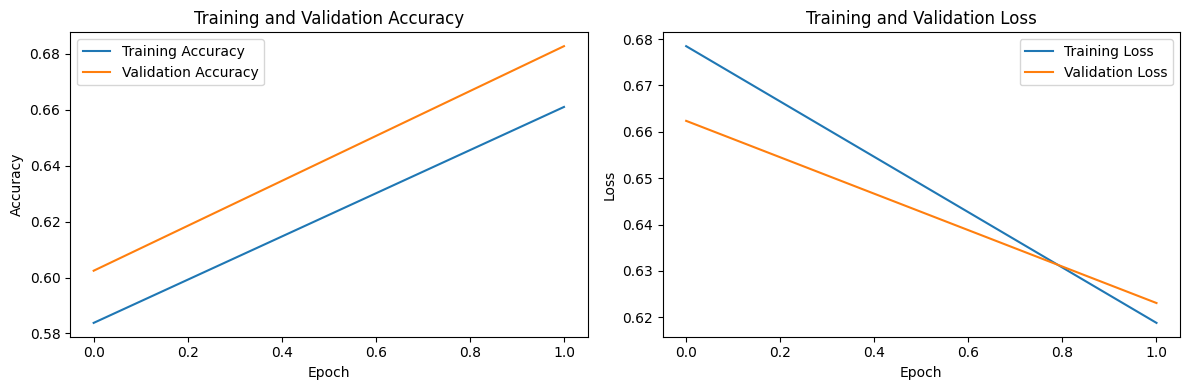

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
